**Đưa dữ liệu về dạng số bằng TfidfVectorizer**<br>
Hàm này tách từng chữ ra vè đếm số lần xuất hiện của mỗi chữ trong mỗi Email, trả về một ma trận thưa (n,m) n là số email m là số từ vựng có đượng trong tập email đó

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv("./emails.csv")
emails = data["text"]
Y = data["spam"] #is spam

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(emails)


W =   np.zeros(X.shape[1])
b = 0


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


**Áp dụng Logistic regression** <br>
Vì dữ liệu train rất lớn và được lưu bằng ma trận thưa, nên sử dụng hàm dot của ma trận thưa, không nên đưa về np vì nó sẽ đưa về ma trận thường rồi mới tính dẫn đến Memory Error.

In [3]:
def Sigmoid(x):
  return 1/(1+ np.exp(-x))

N, = Y_train.shape


NumberOfInteration = 10000
LearningRate = 0.5

for i in range(NumberOfInteration):
  y_predict = Sigmoid(X_train.dot(W) + b)
  error = y_predict - Y_train
  b = b - LearningRate * np.sum(error)/N
  W = W - LearningRate * X_train.T.dot(error)/N

np.savez('model.npz', weights=W, bias=b)

**Đánh giá**<br>
Dùng dữ liệu test đã tách ở phần trước để test và so sánh với output test.

In [4]:
load_weight = np.load('model.npz')

# Truy cập các biến bằng tên
W = load_weight['weights']
b = load_weight['bias']
Y_pob_test = Sigmoid(X_test.dot(W) + b)
Y_pred_test = (Y_pob_test >= 0.5).astype(int)


counter_correct = (Y_pred_test == Y_test).sum()
total_test = Y_test.shape[0]
accuracy = counter_correct / total_test
print("Accuracy on test data: ", accuracy)

Accuracy on test data:  0.9851657940663177


Vẽ biểu đồ dự đoán đúng sai của model

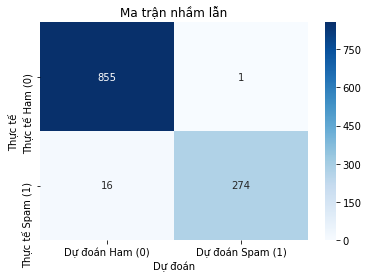

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán Ham (0)', 'Dự đoán Spam (1)'],
            yticklabels=['Thực tế Ham (0)', 'Thực tế Spam (1)'])
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.title('Ma trận nhầm lẫn')
plt.show()